In [1]:
import sys
from pathlib import Path

# Add project root to Python path
project_root = Path("..").resolve()
sys.path.append(str(project_root))

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from experiments.datasets import plot_data
from src.models.mlp1 import Mlp1

In [2]:
raw_tdata = pd.read_csv('../data/raw/training_set.csv', names=('x1', 'x2', 'Targets'))     #header=None,

training_p = len(raw_tdata.index)    #number of rows of training data, 10000

training_set = raw_tdata[['x1', 'x2']].to_numpy()     #for each of the p input patterns two components x1 and x2 and...
training_targets = raw_tdata['Targets'].values         #...a target value for each pattern

In [3]:
#Start by normalizing the data by centering each of the two input components and normalizing their respective variances to 1.
tdata_mean = np.mean(training_set, axis=0)

tdata_std = np.std(training_set, axis=0)

#make zero-mean by subtracting the mean value for each column
for i in range(len(training_set)):
    training_set[i][0] = (training_set[i][0] - tdata_mean[0]) / tdata_std[0]   #subtract x1 mean from x1 column
    training_set[i][1] = (training_set[i][1] - tdata_mean[1]) / tdata_std[1]   #subtract x2 mean from x2 column

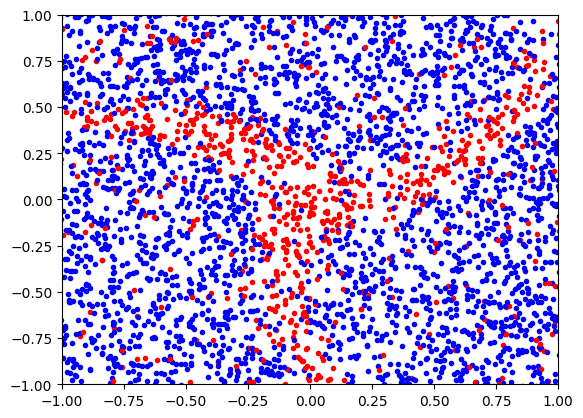

In [ ]:
# Plot, let red refer to the +1 label and blue to -1
for mu in range(training_p):
    if training_targets[mu] == 1 :
        plt.plot(training_set[mu,0],training_set[mu,1],'r.')
    else :
        plt.plot(training_set[mu,0],training_set[mu,1],'b.')

plt.axis([-1, 1, -1, 1])
plt.show()

In [13]:
model = Mlp1(input_dim=2, hidden_dim=10, lr=0.01)

outputs, _ = model.forward(training_set)  # _ is cache, not needed here
w, b = model.W2, model.b2

loss = 0.5 * ((training_targets - outputs)**2).mean()
predictions = model.predict(training_set)
accuracy = (predictions == training_targets).mean()

print(f"Loss before training: {loss:.4f} – Accuracy before training: {accuracy:.2f}")

Loss before training: 0.7514 – Accuracy before training: 0.50


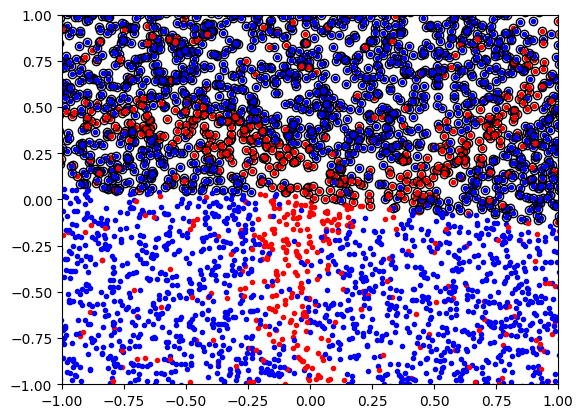

In [14]:
# Plot, let red be in the set
for mu in range(len(training_targets)):
    if training_targets[mu] == 1 :
        plt.plot(training_set[mu,0], training_set[mu,1],'r.')
    else :
        plt.plot(training_set[mu,0], training_set[mu,1],'b.')
    # plot classification of network as circles
    if predictions[mu] == 1 :
        plt.plot(training_set[mu,0], training_set[mu,1],'ko',mfc='none')

plt.axis([-1, 1, -1, 1])
plt.show()

In [15]:
model.fit(training_set, training_targets, 200)

Out = model.predict(training_set)

Epoch 1/200 – Loss: 0.2376 – Accuracy: 0.85
Epoch 2/200 – Loss: 0.2358 – Accuracy: 0.86
Epoch 3/200 – Loss: 0.2344 – Accuracy: 0.86
Epoch 4/200 – Loss: 0.2334 – Accuracy: 0.86
Epoch 5/200 – Loss: 0.2325 – Accuracy: 0.86
Epoch 6/200 – Loss: 0.2317 – Accuracy: 0.86
Epoch 7/200 – Loss: 0.2308 – Accuracy: 0.86
Epoch 8/200 – Loss: 0.2300 – Accuracy: 0.86
Epoch 9/200 – Loss: 0.2291 – Accuracy: 0.86
Epoch 10/200 – Loss: 0.2283 – Accuracy: 0.86
Epoch 11/200 – Loss: 0.2276 – Accuracy: 0.86
Epoch 12/200 – Loss: 0.2270 – Accuracy: 0.86
Epoch 13/200 – Loss: 0.2265 – Accuracy: 0.86
Epoch 14/200 – Loss: 0.2261 – Accuracy: 0.87
Epoch 15/200 – Loss: 0.2257 – Accuracy: 0.87
Epoch 16/200 – Loss: 0.2254 – Accuracy: 0.87
Epoch 17/200 – Loss: 0.2251 – Accuracy: 0.87
Epoch 18/200 – Loss: 0.2248 – Accuracy: 0.87
Epoch 19/200 – Loss: 0.2245 – Accuracy: 0.87
Epoch 20/200 – Loss: 0.2243 – Accuracy: 0.87
Epoch 21/200 – Loss: 0.2241 – Accuracy: 0.87
Epoch 22/200 – Loss: 0.2239 – Accuracy: 0.87
Epoch 23/200 – Loss

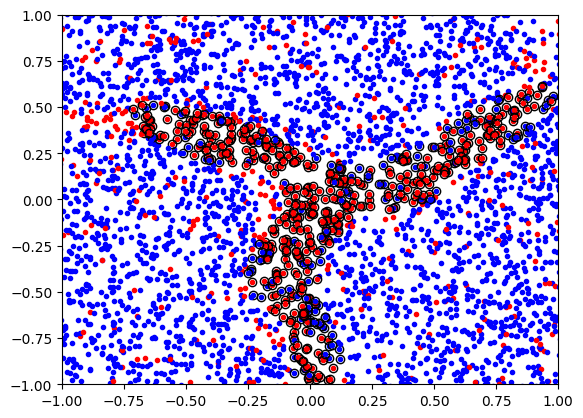

In [16]:
# Plot, let red be in the set
for mu in range(len(training_targets)):
    if training_targets[mu] == 1 :
        plt.plot(training_set[mu,0], training_set[mu,1],'r.')
    else :
        plt.plot(training_set[mu,0], training_set[mu,1],'b.')
    # plot classification of network as circles
    if Out[mu] == 1 :
        plt.plot(training_set[mu,0], training_set[mu,1],'ko',mfc='none')

plt.axis([-1, 1, -1, 1])
plt.show()